# Прогнозирование погоды с помощью нейронных сетей

Чтобы запускать и редактировать код, сохраните копию этого ноутбука себе (Файл -> Создать копию на Диске). Свою копию вы сможете изменять и запускать.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

За основу взят [ноутбук по анализу временных рядов из книги Deel Learning With Python](https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter13_timeseries-forecasting.ipynb).

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/timeseries/weather_tensorflow.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
import numpy as np
import zipfile
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
%matplotlib inline

## Загружаем данные

In [2]:
data_path = 'data'

In [3]:
path = Path(data_path)

if not path.exists():
    path.mkdir(parents=True, exist_ok=True)

In [6]:
!curl -s -L -o data/jena_climate_2009_2016.csv.zip "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip"

In [ ]:
with zipfile.ZipFile("data/jena_climate_2009_2016.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(data_path)

In [10]:
fname = os.path.join("data/jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


## Готовим данные

Извлекаем данные о температуре

In [12]:
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

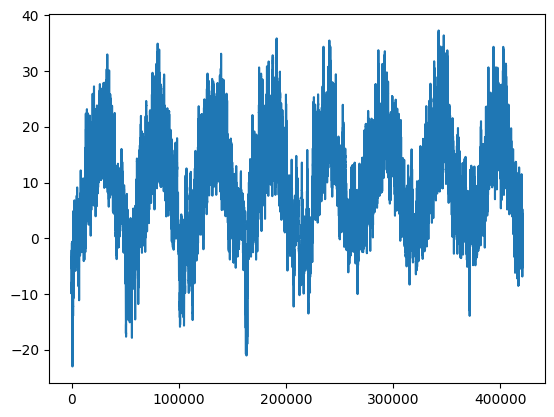

In [13]:
plt.plot(range(len(temperature)), temperature)

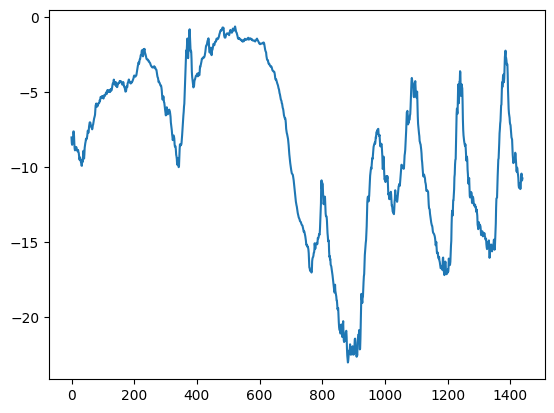

In [14]:
plt.plot(range(1440), temperature[:1440])

Разбиваем данные на обучающий, проверочный и тестовый наборы

In [16]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("Количество измерений в обучающем наборе:", num_train_samples)
print("Количество измерений в проверочном наборе:", num_val_samples)
print("Количество измерений в тестовом наборе:", num_test_samples)

Количество измерений в обучающем наборе: 210225
Количество измерений в проверочном наборе: 105112
Количество измерений в тестовом наборе: 105114


Нормализуем данные

In [17]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

## Создаем Dataset для TensorFlow

Пример работы timeseries_dataset_from_array

In [21]:
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [22]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [ ]:
for samples, targets in train_dataset:
    print("Размерность обучающей мини-выборки:", samples.shape)
    print("Размерность целевой переменной:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


## Создаем базовое решение

Всегда предстказываем последнее значение

In [24]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


## Полносвязная нейронная сеть

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 15.2871 - mae: 2.9706 - val_loss: 10.6678 - val_mae: 2.5712
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 8.9400 - mae: 2.3629 - val_loss: 10.9836 - val_mae: 2.6214
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 8.1806 - mae: 2.2594 - val_loss: 11.2400 - val_mae: 2.6425
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 7.7182 - mae: 2.1951 - val_loss: 11.0342 - val_mae: 2.6219
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 7.4359 - mae: 2.1540 - val_loss: 11.1030 - val_mae: 2.6261
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 7.2210 - mae: 2.1201 - val_loss: 11.2365 - val_mae: 2.6377
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 7.0637 - mae: 2.0958 - val_loss: 11.5139 - val_mae: 2.6679
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 6.8943 - mae: 2.0699 - val_loss: 11.3206 - val_mae: 2.6465
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/

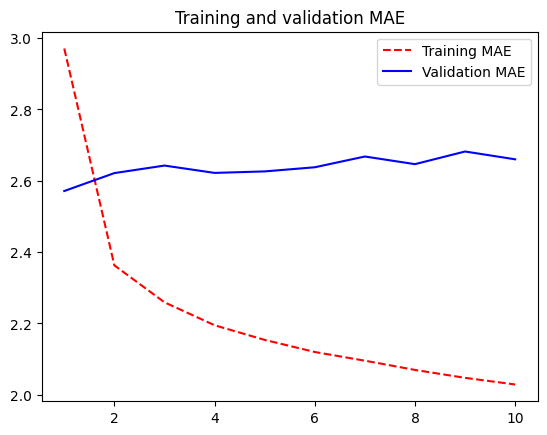

In [ ]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

## Одномерная сверточная нейронная сеть

In [28]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 22.2090 - mae: 3.6638 - val_loss: 15.9323 - val_mae: 3.1248
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 14.0861 - mae: 2.9718 - val_loss: 14.8855 - val_mae: 3.0249
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 12.7763 - mae: 2.8282 - val_loss: 14.6957 - val_mae: 3.0232
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 11.7438 - mae: 2.7116 - val_loss: 14.9677 - val_mae: 3.0524
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 11.0069 - mae: 2.6233 - val_loss: 15.8835 - val_mae: 3.1375
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 10.4438 - mae: 2.5503 - val_loss: 16.4219 - val_mae: 3.2026
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 10.0560 - mae: 2.5007 - val_loss: 16.6507 - val_mae: 3.2111
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 9.7414 - mae: 2.4568 - val_loss: 15.9254 - val_mae: 3.1560
Epoch 9/10
819/819 ━━━━━━━━━

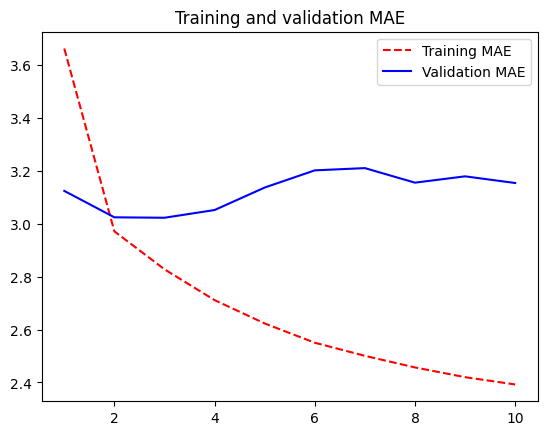

In [30]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

## Сеть LSTM

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")


Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 39.9698 - mae: 4.6094 - val_loss: 15.5247 - val_mae: 2.9599
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 13.2998 - mae: 2.7796 - val_loss: 10.9937 - val_mae: 2.5534
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 10.6654 - mae: 2.5367 - val_loss: 10.1603 - val_mae: 2.4673
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 9.8611 - mae: 2.4516 - val_loss: 9.7695 - val_mae: 2.4234
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 9.4785 - mae: 2.3979 - val_loss: 9.3325 - val_mae: 2.3680
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 9.0635 - mae: 2.3487 - val_loss: 9.2373 - val_mae: 2.3529
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - loss: 8.8174 - mae: 2.3188 - val_loss: 9.4993 - val_mae: 2.3791
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - loss: 8.6589 - mae: 2.2983 - val_loss: 9.5106 - val_mae: 2.3878
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

In [34]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 10.9479 - mae: 2.5834
MAE на тестовом наборе данных: 2.58


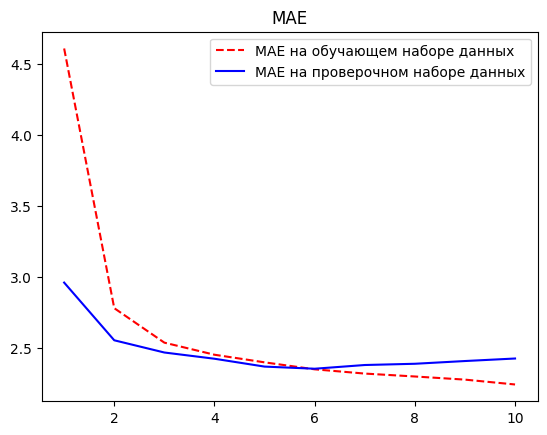

In [33]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

Используем Dropout для снижения переобучения

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 65ms/step - loss: 34.0819 - mae: 4.3050 - val_loss: 11.7798 - val_mae: 2.6200
Epoch 2/50
818/819 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 17.3162 - mae: 3.2202

KeyboardInterrupt: 

In [36]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 11.2712 - mae: 2.5857
MAE на тестовом наборе данных: 2.59


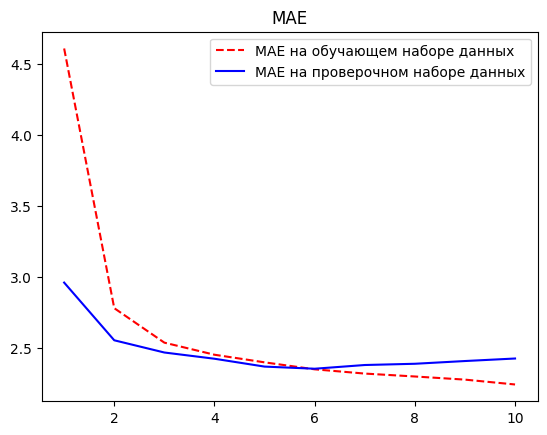

In [37]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

## Несколько рекуррентных слоев

In [38]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 91s 107ms/step - loss: 29.8573 - mae: 4.0187 - val_loss: 10.8789 - val_mae: 2.4956
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 87s 106ms/step - loss: 14.9643 - mae: 2.9855 - val_loss: 9.1810 - val_mae: 2.3285
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 107ms/step - loss: 13.8885 - mae: 2.8803 - val_loss: 8.8030 - val_mae: 2.2903
Epoch 4/20
126/819 ━━━━━━━━━━━━━━━━━━━━ 1:03 91ms/step - loss: 13.7473 - mae: 2.8663

KeyboardInterrupt: 

In [39]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 10.1645 - mae: 2.4881
MAE на тестовом наборе данных: 2.49


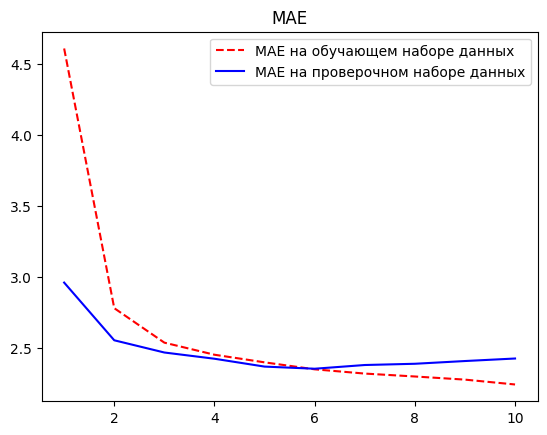

In [40]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

## Используем двунаправленную рекуррентную сеть

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_bidirectional_lstm.keras", save_best_only=True
    )
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

model = keras.models.load_model("jena_bidirectional_lstm.keras")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 32.7602 - mae: 4.1220 - val_loss: 13.5264 - val_mae: 2.8448
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 12.4539 - mae: 2.7414 - val_loss: 11.5631 - val_mae: 2.6465
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 10.6076 - mae: 2.5403 - val_loss: 10.7927 - val_mae: 2.5534
Epoch 4/10
697/819 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 9.8391 - mae: 2.4412

In [ ]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

In [ ]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()